## Import libraries

In [7]:
import numpy as np
from scipy.special import expit
from matplotlib import pyplot as plt

## 1. Logistic regression   
#### Gaussian random number generator in hw3:

In [8]:
class BoxMullerTransform():
    def __init__(self, mean, variance) :
        self.mean = mean
        self.variance = variance
        self.std_dev = np.sqrt(variance)
    def sample_standard_normal(self):
        u1 = np.random.uniform(0, 1)
        u2 = np.random.uniform(0, 1)
        self.x1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 *  np.pi * u2)
        self.x2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)
    def sample_normal(self):
        self.sample_standard_normal()
        p = np.random.random()
        if p < 0.5:
            x = self.x1
        else:
            x = self.x2
        y = self.mean + self.std_dev * x
        
        return y

#### make up dataset

In [9]:
def collect_data(N, mx1, vx1, my1, vy1, mx2, vx2, my2, vy2):
    generator_x1 = BoxMullerTransform(mx1, vx1)
    generator_y1 = BoxMullerTransform(my1, vy1)
    generator_x2 = BoxMullerTransform(mx2, vx2)
    generator_y2 = BoxMullerTransform(my2, vy2)
    cluster_1 = np.zeros((N, 2))
    cluster_2 = np.zeros((N, 2))
    for i in range(N):
        cluster_1[i][0] = generator_x1.sample_normal()
        cluster_1[i][1] = generator_y1.sample_normal()
        cluster_2[i][0] = generator_x2.sample_normal()
        cluster_2[i][1] = generator_y2.sample_normal()
    return cluster_1, cluster_2

In [10]:
class logistic_regression():
    def __init__(self, N, mx1, vx1, my1, vy1, mx2, vx2, my2, vy2):
        self.N = N
        self.cluster_1, self.cluster_2 = collect_data(N, mx1, vx1, my1, vy1, mx2, vx2, my2, vy2)
        self.w_g = np.random.rand(3, 1)    # weights for gradient descent
        self.w_n = np.random.rand(3, 1)    # weights for Newton's method
        self.X , self.Y= self.get_X_Y()    # X = (x, y, 1), Y = Bernoulli(x, y, 1)
        self.predictions = np.zeros((2, 2 * self.N)) 
    def get_X_Y(self):
        ones_1 = np.ones((self.cluster_1.shape[0], 1))
        ones_2 = np.ones((self.cluster_2.shape[0], 1))
        X_1 = np.hstack((self.cluster_1, ones_1))
        X_2 = np.hstack((self.cluster_2, ones_2))
        X = np.vstack((X_1, X_2))
        Y = np.zeros((self.cluster_1.shape[0] + self.cluster_2.shape[0], 1))
        Y[self.cluster_1.shape[0]: , 0] = 1
        return X, Y
    
    def get_Hessain(self):
        D = np.zeros((2 * self.N, 2 * self.N), dtype=np.double)
        for i in range(2 * self.N):
            D[i][i] = expit((self.X[i] @ (self.w_n)).item()) / ((1 + expit((self.X[i] @ self.w_n).item())) ** 2)
        Hessian = np.transpose(self.X) @ D @ self.X
        return Hessian
    
    def evaluate_gradient_regression(self):
        delta_J = np.full((3, 1), float('inf'))
        count = 0
        while np.abs(delta_J).max() >= 1e-6 and count <= 100000:
            delta_J = np.transpose(self.X) @ (self.Y - expit(self.X @ self.w_g))
            count += 1
            self.w_g += delta_J
    def evaluate_newtons_regression(self):
        count = 0
        w_diff = np.full((3, 1), float('inf'))
        while w_diff.max() >= 1e-6 or count <= 10:
            count += 1
            H = self.get_Hessain()
            delta_J = np.transpose(self.X) @ (self.Y - expit(self.X @ self.w_n))
            old_w_n = self.w_n
            if np.linalg.det(H) == 0:
                self.w_n += delta_J
            else:
                self.w_n += (np.linalg.inv(H) @ delta_J)
            w_diff = np.abs(old_w_n - self.w_n)

    def get_predictions(self):
        self.evaluate_gradient_regression()
        self.evaluate_newtons_regression()
        weights = [self.w_g, self.w_n]
        for i, w in enumerate(weights):
            y_pred = np.where(self.X @ w  > 0, 1, 0)
            self.predictions[i] = y_pred.reshape(-1)
            tp = np.sum((y_pred == 1) & (self.Y == 1))
            tn = np.sum((y_pred == 0) & (self.Y == 0)) 
            if i == 0:
                print(f'Gradient descent: \n')
            else:
                print(f'Newton\'s method: \n')
            print(f'w: \n  {w[0].item(): .10f}\n  {w[1].item(): .10f}\n  {w[2].item(): .10f}\n')
            print('Confusion Matrix: \n             Predict cluster 1 Predict cluster 2')
            print(f'Is cluster 1        {tn}               {self.N - tn}')
            print(f'Is cluster 2        {self.N - tp}               {tp}\n')
            print(f'Sensitivity (Successfully predict cluster 1): {tn/self.N: .5f}')
            print(f'Specificity (Successfully predict cluster 2): {tp/self.N: .5f}')
            print('\n----------------------------------------------------------------')
    def plot(self):
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        x_1 = self.cluster_1[:, 0]
        y_1 = self.cluster_1[:, 1]
        x_2 = self.cluster_2[:, 0]
        y_2 = self.cluster_2[:, 1]
        x_all = np.concatenate([x_1, x_2])
        y_all = np.concatenate([y_1, y_2])

        axs[0].scatter(x_1, y_1, color='red')
        axs[0].scatter(x_2, y_2, color='blue')
        axs[0].set_title('Ground truth')

        cluster_0_g = (self.predictions[0] == 0)
        cluster_1_g = (self.predictions[0] == 1) 
        axs[1].scatter(x_all[cluster_0_g], y_all[cluster_0_g], color='red')
        axs[1].scatter(x_all[cluster_1_g], y_all[cluster_1_g], color='blue')
        axs[1].set_title('Gradient descent')

        cluster_0_n = (self.predictions[1] == 0)
        cluster_1_n = (self.predictions[1] == 1) 
        axs[2].scatter(x_all[cluster_0_n], y_all[cluster_0_n], color='red')
        axs[2].scatter(x_all[cluster_1_n], y_all[cluster_1_n], color='blue')
        axs[2].set_title('Newton\'s method')
        plt.tight_layout()
        plt.show()


## Experiment

logistic_regression(N, mx1, vx1, my1, vy1, mx2, vx2, my2, vy2)  
case 1: N = 50, mx1 = 1, my1 = 1, mx2 = 10, my2 = 10, vx1 = 2, vy1 = 2, vx2 = 2, vy2 = 2

Gradient descent: 

w: 
   17.0441766229
   51.1019494034
  -288.9361228691

Confusion Matrix: 
             Predict cluster 1 Predict cluster 2
Is cluster 1        50               0
Is cluster 2        0               50

Sensitivity (Successfully predict cluster 1):  1.00000
Specificity (Successfully predict cluster 2):  1.00000

----------------------------------------------------------------
Newton's method: 

w: 
   1.5752003766
   1.0696432239
  -13.0897631017

Confusion Matrix: 
             Predict cluster 1 Predict cluster 2
Is cluster 1        50               0
Is cluster 2        0               50

Sensitivity (Successfully predict cluster 1):  1.00000
Specificity (Successfully predict cluster 2):  1.00000

----------------------------------------------------------------


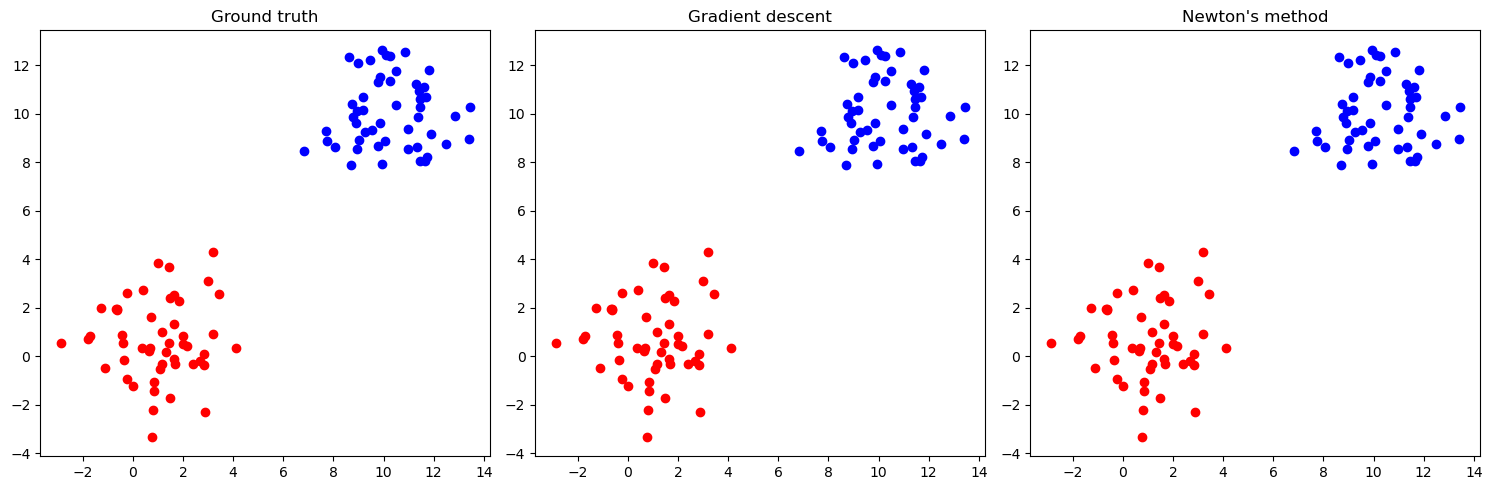

In [11]:
case_1 = logistic_regression(50, 1, 2, 1, 2, 10, 2, 10, 2)
case_1.get_predictions()
case_1.plot()

case 2: N = 50, mx1 = 1, my1 = 1, mx2 = 3, my2 = 3, vx1 = 2, vy1 = 2, vx2 = 4, vy2 = 4

Gradient descent: 

w: 
   54.3833409291
   41.4434253959
  -150.6027262135

Confusion Matrix: 
             Predict cluster 1 Predict cluster 2
Is cluster 1        38               12
Is cluster 2        7               43

Sensitivity (Successfully predict cluster 1):  0.76000
Specificity (Successfully predict cluster 2):  0.86000

----------------------------------------------------------------
Newton's method: 

w: 
   0.9710302191
   0.8082770923
  -3.3266030453

Confusion Matrix: 
             Predict cluster 1 Predict cluster 2
Is cluster 1        42               8
Is cluster 2        10               40

Sensitivity (Successfully predict cluster 1):  0.84000
Specificity (Successfully predict cluster 2):  0.80000

----------------------------------------------------------------


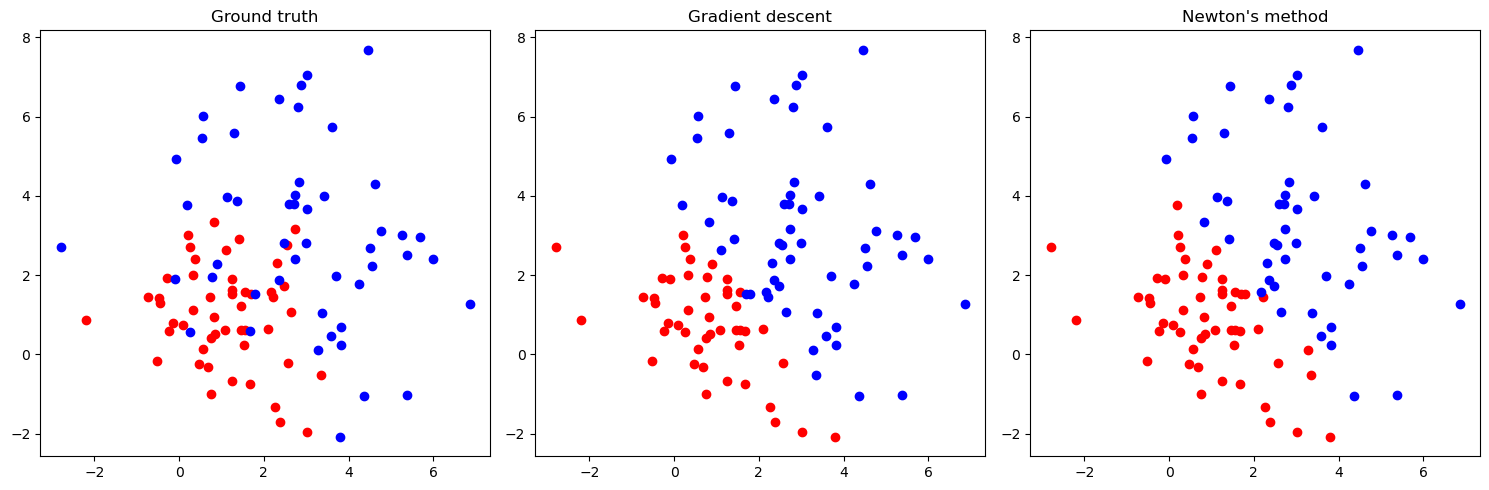

In [12]:
case_2 = logistic_regression(50, 1, 2, 1, 2, 3, 4, 3, 4)
case_2.get_predictions()
case_2.plot()